# Hypothesis Testing

This notebook performs formal statistical hypothesis tests for the project **"What Makes a Rock Song a Hit?"**.

The purpose of this stage is to test whether selected audio features and rock subgenres show statistically meaningful differences related to hit status and popularity.

The methods used here are aligned with the course lectures:
- **two-sample t-test** for comparing means between two independent groups,
- **one-way ANOVA** for comparing means across more than two groups.

In [3]:
import pandas as pd
from scipy.stats import ttest_ind, f_oneway
import matplotlib.pyplot as plt
import seaborn as sns

rock_df = pd.read_csv("data/clean/rock_dataset_cleaned.csv")

sns.set_theme(style="whitegrid", context="talk", palette="flare")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13

print(rock_df.shape)
rock_df.head()

(5877, 24)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,instrumentalness,liveness,valence,tempo,time_signature,track_genre,is_hit,track_name_length,artist_count,duration_min
0,4h9wh7iOZ0GGn8QVp4RAOB,OneRepublic,I Ain’t Worried (Music From The Motion Picture...,I Ain't Worried,96,148485,False,0.704,0.797,0,...,0.000745,0.0546,0.825,139.994,4,rock,1,15,1,2.474750
1,2QjOHCTQ1Jl3zawyYOpxh6,The Neighbourhood,I Love You.,Sweater Weather,93,240400,False,0.612,0.807,10,...,0.017700,0.1010,0.398,124.053,4,rock,1,15,1,4.006667
2,5XeFesFbtLpXzIVDNQP22n,Arctic Monkeys,AM,I Wanna Be Yours,92,183956,False,0.464,0.417,0,...,0.022000,0.0974,0.479,67.528,4,rock,1,16,1,3.065933
3,75FEaRjZTKLhTrFGsfMUXR,Kate Bush,Hounds Of Love,Running Up That Hill (A Deal With God),90,298933,False,0.629,0.547,10,...,0.003140,0.0604,0.197,108.375,4,rock,1,38,1,4.982217
4,7DbdUf8aHSYoliSjO6LZv6,Beach Weather,Chit Chat,"Sex, Drugs, Etc.",90,196784,False,0.572,0.839,4,...,0.009760,0.5220,0.465,143.969,4,rock,1,16,1,3.279733


## Hypothesis 1: Acousticness in Hit vs Non-Hit Songs

### Null Hypothesis ($H_0$)
The mean acousticness is the same for hit and non-hit songs.

### Alternative Hypothesis ($H_A$)
The mean acousticness differs between hit and non-hit songs.

Since this compares the means of two independent groups, a two-sample t-test is used.

In [4]:
hit_acoustic = rock_df.loc[rock_df["is_hit"] == 1, "acousticness"]
nonhit_acoustic = rock_df.loc[rock_df["is_hit"] == 0, "acousticness"]

t_stat_ac, p_val_ac = ttest_ind(hit_acoustic, nonhit_acoustic, equal_var=False)

print("H1: Acousticness in hit vs non-hit songs")
print(f"t-statistic: {t_stat_ac:.4f}")
print(f"p-value: {p_val_ac:.6f}")
print(f"Mean acousticness (Hit): {hit_acoustic.mean():.4f}")
print(f"Mean acousticness (Non-Hit): {nonhit_acoustic.mean():.4f}")

H1: Acousticness in hit vs non-hit songs
t-statistic: -7.4241
p-value: 0.000000
Mean acousticness (Hit): 0.1985
Mean acousticness (Non-Hit): 0.2576


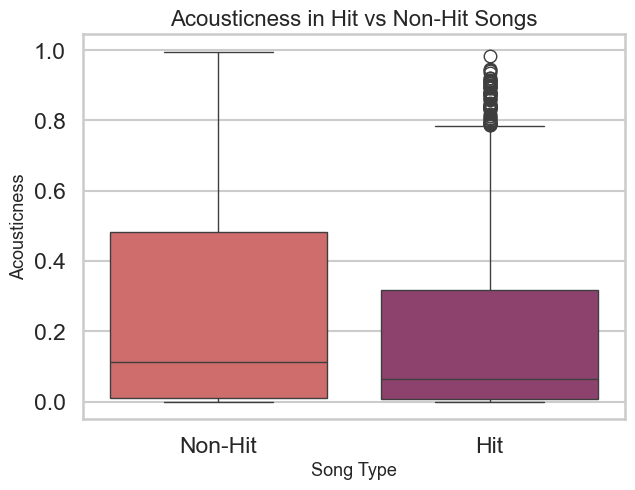

In [5]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=rock_df, x="is_hit", y="acousticness", hue="is_hit", legend=False, palette="flare")
plt.xticks([0, 1], ["Non-Hit", "Hit"])
plt.title("Acousticness in Hit vs Non-Hit Songs")
plt.xlabel("Song Type")
plt.ylabel("Acousticness")
plt.show()

### Interpretation

If the p-value is below 0.05, the null hypothesis is rejected, suggesting that hit and non-hit songs differ significantly in mean acousticness.

If the p-value is greater than 0.05, then the data do not provide enough evidence for a difference in mean acousticness between the two groups.

### Conclusion

The two-sample t-test showed a statistically significant difference in mean acousticness between hit and non-hit songs (`p < 0.001`). Therefore, the null hypothesis is rejected.

In the cleaned rock dataset, hit songs have lower average acousticness than non-hit songs. This suggests that less acoustic rock songs may be more likely to fall into the hit category.

-----------------------------------------

## Hypothesis 2: Danceability in Hit vs Non-Hit Songs

### Null Hypothesis ($H_0$)
The mean danceability is the same for hit and non-hit songs.

### Alternative Hypothesis ($H_A$)
The mean danceability differs between hit and non-hit songs.

A two-sample t-test is again used because the comparison is between two independent groups.

In [6]:
hit_dance = rock_df.loc[rock_df["is_hit"] == 1, "danceability"]
nonhit_dance = rock_df.loc[rock_df["is_hit"] == 0, "danceability"]

t_stat_da, p_val_da = ttest_ind(hit_dance, nonhit_dance, equal_var=False)

print("H2: Danceability in hit vs non-hit songs")
print(f"t-statistic: {t_stat_da:.4f}")
print(f"p-value: {p_val_da:.6f}")
print(f"Mean danceability (Hit): {hit_dance.mean():.4f}")
print(f"Mean danceability (Non-Hit): {nonhit_dance.mean():.4f}")

H2: Danceability in hit vs non-hit songs
t-statistic: -3.5117
p-value: 0.000452
Mean danceability (Hit): 0.5122
Mean danceability (Non-Hit): 0.5261


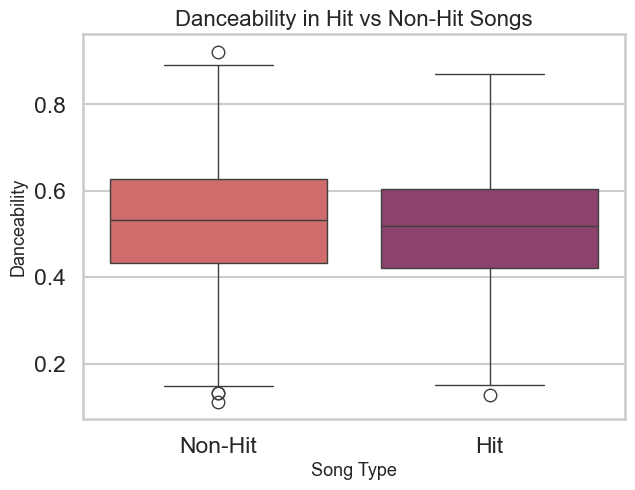

In [7]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=rock_df, x="is_hit", y="danceability", hue="is_hit", legend=False, palette="flare")
plt.xticks([0, 1], ["Non-Hit", "Hit"])
plt.title("Danceability in Hit vs Non-Hit Songs")
plt.xlabel("Song Type")
plt.ylabel("Danceability")
plt.show()

### Conclusion

The two-sample t-test showed a statistically significant difference in mean danceability between hit and non-hit songs (`p < 0.001`). Therefore, the null hypothesis is rejected.

Although the difference is statistically significant, the mean values are relatively close. This suggests that danceability may have some relationship with hit status, but the effect appears modest in practical terms.

-------------------------------

## Hypothesis 3: Popularity Across Rock Subgenres

### Null Hypothesis ($H_0$)
The mean popularity is the same across all rock subgenres.

### Alternative Hypothesis ($H_A$)
At least one rock subgenre has a different mean popularity.

Since this compares means across more than two groups, a one-way ANOVA is used.

In [8]:
subgenre_groups = [
    group["popularity"].values
    for _, group in rock_df.groupby("track_genre")
]

anova_stat, anova_p = f_oneway(*subgenre_groups)

print("H3: Popularity across rock subgenres")
print(f"F-statistic: {anova_stat:.4f}")
print(f"p-value: {anova_p:.6f}")

H3: Popularity across rock subgenres
F-statistic: 72.9117
p-value: 0.000000


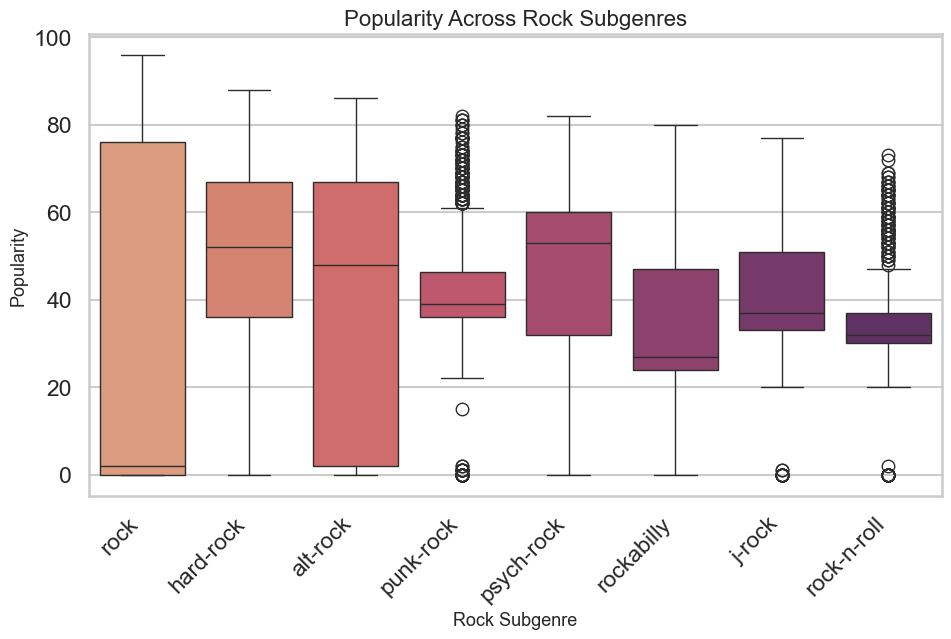

In [9]:
plt.figure(figsize=(11, 6))
sns.boxplot(data=rock_df, x="track_genre", y="popularity", hue="track_genre", legend=False, palette="flare")
plt.title("Popularity Across Rock Subgenres")
plt.xlabel("Rock Subgenre")
plt.ylabel("Popularity")
plt.xticks(rotation=45, ha="right")
plt.show()

### Interpretation

If the p-value is below 0.05, the null hypothesis is rejected, meaning that at least one rock subgenre differs in mean popularity from the others.

If the result is significant, this suggests that subgenre may be an important structural factor in explaining popularity.

### Conclusion

The one-way ANOVA showed a statistically significant difference in mean popularity across rock subgenres (`p < 0.001`). Therefore, the null hypothesis is rejected.

This indicates that at least one rock subgenre differs from the others in average popularity. Subgenre appears to be an important structural factor in the dataset and may help explain popularity differences among rock songs.

In [10]:
results = pd.DataFrame({
    "Hypothesis": [
        "H1: Acousticness in hit vs non-hit songs",
        "H2: Danceability in hit vs non-hit songs",
        "H3: Popularity across rock subgenres"
    ],
    "Test": [
        "Two-sample t-test",
        "Two-sample t-test",
        "One-way ANOVA"
    ],
    "Statistic": [
        t_stat_ac,
        t_stat_da,
        anova_stat
    ],
    "P-value": [
        p_val_ac,
        p_val_da,
        anova_p
    ]
})

results

,Hypothesis,Test,Statistic,P-value
0,H1: Acousticness in hit vs non-hit songs,Two-sample t-test,-7.424089,1.470952e-13
1,H2: Danceability in hit vs non-hit songs,Two-sample t-test,-3.511692,4.524163e-04
2,H3: Popularity across rock subgenres,One-way ANOVA,72.911724,1.375607e-101


## Final Summary

This notebook tested three hypotheses relevant to the project question:

- whether hit and non-hit songs differ in **acousticness**,
- whether hit and non-hit songs differ in **danceability**,
- and whether **popularity** differs across rock subgenres.

Together, these tests provide a formal statistical follow-up to the exploratory data analysis and help identify which audio-related differences are meaningful enough to carry forward into later modeling.